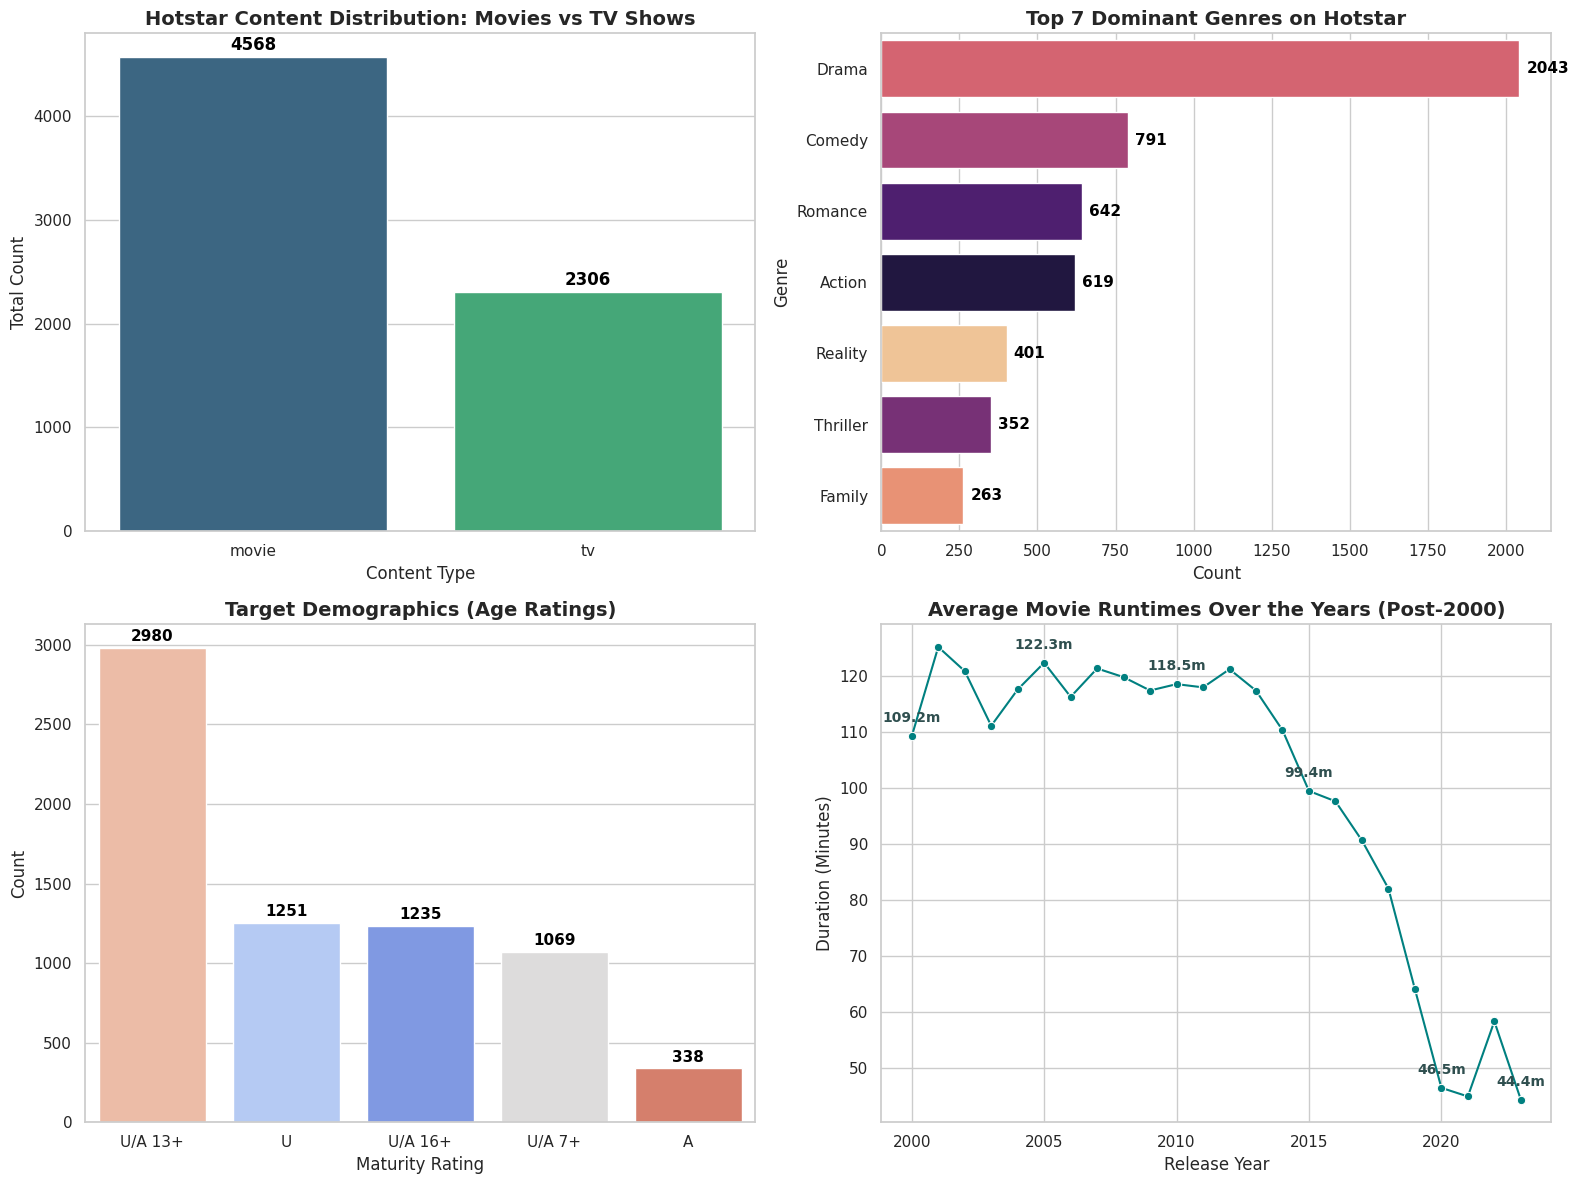


              ★ DISNEY+ HOTSTAR CATALOG DATA SCIENCE SUMMARY ★
• Content Mix Strategy: The catalog features 4,568 Movies vs 2,306 TV Shows.
  Insight: Hotstar positions itself heavily as a digital cinema platform rather than
  focusing primarily on daily episodic series.
--------------------------------------------------------------------------------
• Genre Dominance: Drama takes the top spot with 2,043 titles, followed by
  Comedy (791 titles) and Romance (642 titles).
  Insight: High-emotion, narrative storytelling drives the core audience retention.
--------------------------------------------------------------------------------
• Target Demographics: Family & Youth content dominates. U/A 13+ holds a massive
  2,980 titles, followed by U (1,251 titles) and U/A 16+ (1,235 titles).
  Insight: Content ingestion rules favor high-reach, multi-generational demographics.
--------------------------------------------------------------------------------
• The Runtime Compression Trend:
  In

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Read the dataset
df = pd.read_csv('hotstar.csv')

# 2. Setup the visualization canvas
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Content Type Breakdown with Exact Counts
ax1 = sns.countplot(x='type', data=df, ax=axes[0, 0], hue='type', palette='viridis')
axes[0, 0].set_title('Hotstar Content Distribution: Movies vs TV Shows', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Content Type')
axes[0, 0].set_ylabel('Total Count')
if axes[0, 0].get_legend(): axes[0, 0].get_legend().remove()
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                    textcoords='offset points', fontweight='bold')

# Chart 2: Top Genres with Exact Counts
top_genres_list = df['genre'].value_counts().head(7).index
ax2 = sns.countplot(y='genre', data=df[df['genre'].isin(top_genres_list)], order=top_genres_list, ax=axes[0, 1], hue='genre', palette='magma')
axes[0, 1].set_title('Top 7 Dominant Genres on Hotstar', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('Genre')
if axes[0, 1].get_legend(): axes[0, 1].get_legend().remove()
for p in ax2.patches:
    if p.get_width() > 0:
        ax2.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=11, color='black', xytext=(5, 0),
                    textcoords='offset points', fontweight='bold')

# Chart 3: Age Demographics with Exact Counts
top_ratings_list = df['age_rating'].value_counts().head(5).index
ax3 = sns.countplot(x='age_rating', data=df[df['age_rating'].isin(top_ratings_list)], order=top_ratings_list, ax=axes[1, 0], hue='age_rating', palette='coolwarm')
axes[1, 0].set_title('Target Demographics (Age Ratings)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Maturity Rating')
axes[1, 0].set_ylabel('Count')
if axes[1, 0].get_legend(): axes[1, 0].get_legend().remove()
for p in ax3.patches:
    if p.get_height() > 0:
        ax3.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                    textcoords='offset points', fontweight='bold')

# Chart 4: Evolution of Movie Runtimes with Benchmark Labels
movies_df = df[(df['type'] == 'movie') & (df['year'] >= 2000)].dropna(subset=['running_time'])
yearly_avg = movies_df.groupby('year')['running_time'].mean().reset_index()
sns.lineplot(x='year', y='running_time', data=yearly_avg, ax=axes[1, 1], color='teal', marker='o')
axes[1, 1].set_title('Average Movie Runtimes Over the Years (Post-2000)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Release Year')
axes[1, 1].set_ylabel('Duration (Minutes)')
for x, y in zip(yearly_avg['year'], yearly_avg['running_time']):
    if x in [2000, 2005, 2010, 2015, 2020, 2023]:
        axes[1, 1].annotate(f'{y:.1f}m', (x, y), textcoords="offset points", xytext=(0,10),
                            ha='center', fontsize=10, fontweight='bold', color='darkslategray')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 3. DYNAMIC METRIC EXTRACTION FROM THE DATAFRAME
# ------------------------------------------------------------------------------
# Calculating figures live from the source data
calc_movies = len(df[df['type'] == 'movie'])
calc_tv = len(df[df['type'] == 'tv'])

genre_counts = df['genre'].value_counts()
g1_name, g1_val = genre_counts.index[0], genre_counts.values[0]
g2_name, g2_val = genre_counts.index[1], genre_counts.values[1]
g3_name, g3_val = genre_counts.index[2], genre_counts.values[2]

rating_counts = df['age_rating'].value_counts()
r1_name, r1_val = rating_counts.index[0], rating_counts.values[0]
r2_name, r2_val = rating_counts.index[1], rating_counts.values[1]
r3_name, r3_val = rating_counts.index[2], rating_counts.values[2]

# Pull runtimes dynamically for analysis text
runtime_series = yearly_avg.set_index('year')['running_time']
peak_year = runtime_series.idxmax()
peak_val = runtime_series.max()
latest_year = runtime_series.index[-1]
latest_val = runtime_series.iloc[-1]

# ------------------------------------------------------------------------------
# 4. PRINTING THE DYNAMIC EXECUTIVE REPORT
# ------------------------------------------------------------------------------
print("\n" + "="*80)
print("              ★ JioHOTSTAR CATALOG DATA SCIENCE SUMMARY ★")
print("="*80)
print(f"• Content Mix Strategy: The catalog features {calc_movies:,} Movies vs {calc_tv:,} TV Shows.")
print("  Insight: Hotstar positions itself heavily as a digital cinema platform rather than")
print("  focusing primarily on daily episodic series.")
print("-"*80)
print(f"• Genre Dominance: {g1_name} takes the top spot with {g1_val:,} titles, followed by")
print(f"  {g2_name} ({g2_val:,} titles) and {g3_name} ({g3_val:,} titles).")
print("  Insight: High-emotion, narrative storytelling drives the core audience retention.")
print("-"*80)
print(f"• Target Demographics: Family & Youth content dominates. {r1_name} holds a massive")
print(f"  {r1_val:,} titles, followed by {r2_name} ({r2_val:,} titles) and {r3_name} ({r3_val:,} titles).")
print("  Insight: Content ingestion rules favor high-reach, multi-generational demographics.")
print("-"*80)
print("• The Runtime Compression Trend:")
print(f"  Insight: Average movie lengths shifted post-2015, dropping from a historical")
print(f"  peak of {peak_val:.1f} minutes in {peak_year} down to a modern average of {latest_val:.1f} minutes in {latest_year}.")
print("  This data pattern explicitly proves a platform pivot towards fast-paced short-form digital entries.")
print("="*80 + "\n")